In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from AppearanceManifold.Geodesic_Improved import Get_Geodesic_Distance_Matrix
from AppearanceManifold.MDS import visualize_MDS_Graph
from AppearanceManifold.MDS import Get_MDS_graph
from AppearanceManifold.KNN import Get_KNN_graph


import matplotlib.pyplot as plt
import numpy as np
import time

from DownSampler import load_and_downsample
from SampleCombiner import combine_to_7d_tensor, combine_to_7d

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def visualize_sample(data):
    """
    data: np.ndarray (H, W, 7)
    """

    assert data.ndim == 3 and data.shape[2] == 7

    diffuse = data[..., 0:3]
    specular = data[..., 3:6]
    roughness = data[..., 6]

    # -----------------------------
    # Clamp (안전)
    # -----------------------------
    diffuse = np.clip(diffuse, 0.0, 1.0)
    specular = np.clip(specular, 0.0, 1.0)
    roughness = np.clip(roughness, 0.0, 1.0)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    # Diffuse (RGB)
    axes[0].imshow(diffuse)
    axes[0].set_title("Diffuse (RGB)")
    axes[0].axis("off")

    # Specular (RGB)
    axes[1].imshow(specular)
    axes[1].set_title("Specular (RGB)")
    axes[1].axis("off")

    # Roughness (Heatmap)
    im = axes[2].imshow(roughness, cmap='jet')
    axes[2].set_title("Roughness")
    axes[2].axis("off")

    fig.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

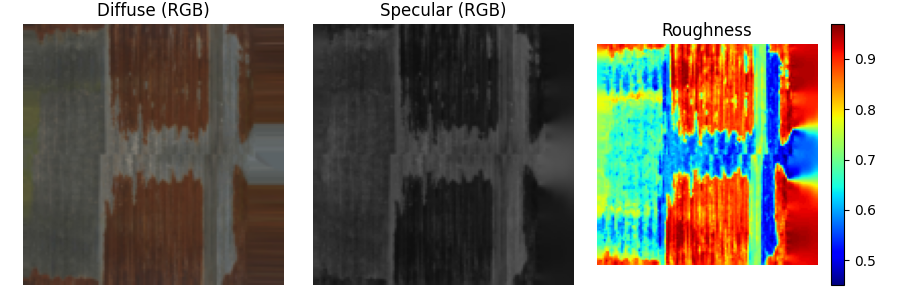

In [4]:
DPath = "./Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_BaseColor.png"
SPath = "./Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_Specular.png"
RPath = "./Military_Trenches_Wall_Metal_Corrugated_03_yd0jdits_Mid_2K_Roughness.png"
D,S,R = load_and_downsample(DPath, SPath, RPath, 128)

X = combine_to_7d_tensor(D,S,R) # 2차원 이미지 형태
FX = combine_to_7d(D,S,R)       # 1차원 배열

visualize_sample(X)

In [5]:
def normalize_features(X):

    X = X.astype(np.float32)

    mean = np.mean(X, axis=0, keepdims=True)
    std = np.std(X, axis=0, keepdims=True)

    return (X - mean) / (std + 1e-8)

In [6]:
X = normalize_features(FX)

In [7]:
start = time.perf_counter()
edge_src, edge_dst, edge_weight, scores = Get_KNN_graph(X)
print("KNN Start")
end = time.perf_counter()
print("KNN Done")
print("Execution Time : " + str(end-start))

Distances :
[[0.02893656 0.15070182 0.24122278 ... 1.19047974 1.19047974 1.19159993]
 [0.02893656 0.12980663 0.22506111 ... 1.180658   1.18236354 1.18236354]
 [0.10075291 0.12980663 0.15070182 ... 1.08325056 1.09287005 1.09546942]
 ...
 [0.         0.05459654 0.106789   ... 0.22098169 0.22098169 0.22241775]
 [0.05459666 0.106789   0.106789   ... 0.22761623 0.22814966 0.22891849]
 [0.05459666 0.11993617 0.11993617 ... 0.22911284 0.23068503 0.23457767]]

Indices :
[[    1     2     3 ... 15989 15990 16302]
 [    0     2     3 ... 16302 15989 15990]
 [    3     1     0 ... 15229 15226 16371]
 ...
 [16380 16379 16382 ... 15863 15864   368]
 [16383 16381 16380 ...   849  2031 16305]
 [16382 16380 16381 ...  1135   829 15869]]
KNN Start
KNN Done
Execution Time : 0.6121280999996088


In [ ]:

print("Geodesic Start")
start = end
D_normal = Get_Geodesic_Distance_Matrix(edge_src, edge_dst, edge_weight, X.shape[0], mode = "normal")
end = time.perf_counter()
print("Execution Time : " + str(end-start))

D = D_normal
print("Geodesic Done")
# execution time : 60~121s

Geodesic Start
Execution Time : 119.75607969999874
Execution Time : 121.81535140000051
Geodesic Done


In [9]:
start = end


print("MDS Start")
Z = Get_MDS_graph(D,dim=3, mode="normal")
end = time.perf_counter()
print("Execution Time : " + str(end-start))
print("MDS Done")
# execution time : 70~92s

MDS Start
Execution Time : 97.02136820000123
MDS Done


In [ ]:
def visualize_final(Z, data_7d):
    roughness = data_7d[:, 6]
    colors = data_7d[:, 0:3]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(
        Z[:, 0],
        Z[:, 1],
        Z[:, 2],
        c=colors,
        s=1
    )

    plt.show()
    
visualize_final(Z, FX)

NameError: name 'Z' is not defined

### 가장 최적(?)인 그래프 생성기로 평면 데이터 시각화 ###

TODO : plane / cylinder 옆면 절반 / hemisphere상에서 균일하게 표본 sampling 했을 떄 geodesic 등이 올바르게 나오고 있는지 테스트 추가

In [1]:
from scipy.spatial.transform import Rotation

n = 20
N = 20*20
Y, X = np.mgrid[:n, :n]

NameError: name 'np' is not defined

In [ ]:
#R = Rotation.from_rotvec([1, 0, 1]).as_matrix()
#XYZ = (R @ np.stack([X, Y, np.ones_like(X)], -1)[..., None]).squeeze(-1)
#print(f"{XYZ.shape = }")

R = Rotation.from_rotvec([1, 0, 1]).as_matrix()

vec = np.stack([X,Y, np.ones_like(X),X**2,Y**2,X*Y,np.sin(X)], axis=-1)

vec_rot = vec.copy()

XYZ = vec_rot[..., :3] = (R @ vec[..., :3, None]).squeeze(-1)

print(vec_rot.shape)
print(f"{vec_rot.shape = }")

(20, 20, 7)
XYZ.shape = (20, 20, 3)


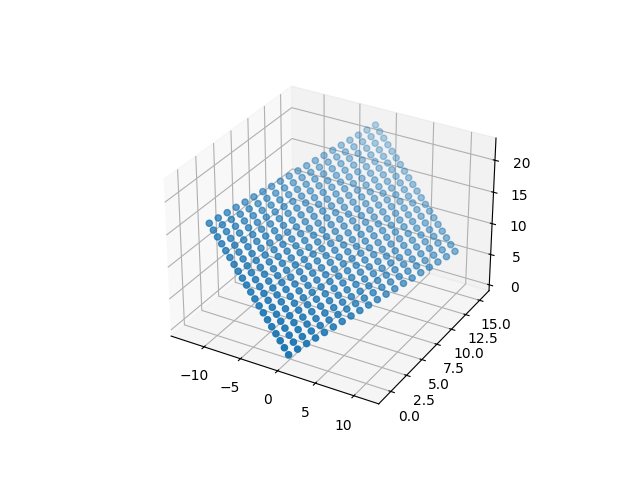

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*np.moveaxis(XYZ, -1, 0))

In [ ]:
m = np.moveaxis(XYZ.reshape(N, 3), 0, 1)
print(f"{m.shape = }")

m = m.transpose()
print(f"{m.shape = }")

m = np.moveaxis(vec_rot.reshape(N, 7), 0, 1)
print(f"{m.shape = }")

m = m.transpose()
print(f"{m.shape = }")

m = m.reshape(20, 20, 7)

m.shape = (3, 400)
m.shape = (400, 3)
m.shape = (7, 400)
m.shape = (400, 7)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def visualize_sample(data):
    """
    data: np.ndarray (H, W, 7)
    """

    assert data.ndim == 3 and data.shape[2] == 7

    diffuse = data[..., 0:3]
    specular = data[..., 3:6]
    roughness = data[..., 6]

    # -----------------------------
    # Clamp (안전)
    # -----------------------------
    diffuse = np.clip(diffuse, 0.0, 1.0)
    specular = np.clip(specular, 0.0, 1.0)
    roughness = np.clip(roughness, 0.0, 1.0)

    # -----------------------------
    # Plot
    # -----------------------------
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    # Diffuse (RGB)
    axes[0].imshow(diffuse)
    axes[0].set_title("Diffuse (RGB)")
    axes[0].axis("off")

    # Specular (RGB)
    axes[1].imshow(specular)
    axes[1].set_title("Specular (RGB)")
    axes[1].axis("off")

    # Roughness (Heatmap)
    im = axes[2].imshow(roughness, cmap='jet')
    axes[2].set_title("Roughness")
    axes[2].axis("off")

    fig.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_sample(m)

In [ ]:
print(f"{m[:, 0] = }")
#print(f"{m[:, 19] = }")
#print(f"{m[:, N-20] = }")
#print(f"{m[:, N-21] = }")

M=normalize_features(m)

m[:, 0] = array([ 4.22028153e-01,  1.00000000e+00,  1.57797185e+00,  2.15594369e+00,
        2.73391554e+00,  3.31188739e+00,  3.88985924e+00,  4.46783108e+00,
        5.04580293e+00,  5.62377478e+00,  6.20174663e+00,  6.77971847e+00,
        7.35769032e+00,  7.93566217e+00,  8.51363402e+00,  9.09160586e+00,
        9.66957771e+00,  1.02475496e+01,  1.08255214e+01,  1.14034933e+01,
       -2.76427846e-01,  3.01544001e-01,  8.79515849e-01,  1.45748770e+00,
        2.03545954e+00,  2.61343139e+00,  3.19140324e+00,  3.76937509e+00,
        4.34734693e+00,  4.92531878e+00,  5.50329063e+00,  6.08126248e+00,
        6.65923432e+00,  7.23720617e+00,  7.81517802e+00,  8.39314986e+00,
        8.97112171e+00,  9.54909356e+00,  1.01270654e+01,  1.07050373e+01,
       -9.74883845e-01, -3.96911997e-01,  1.81059850e-01,  7.59031697e-01,
        1.33700354e+00,  1.91497539e+00,  2.49294724e+00,  3.07091909e+00,
        3.64889093e+00,  4.22686278e+00,  4.80483463e+00,  5.38280648e+00,
        5.96077

In [ ]:
edge_src, edge_dst, edge_weight, scores = Get_KNN_graph(M)
print("------ edge_src ------")
print(edge_src)

print("------ edge_dst ------")
print(edge_dst)

print("------ edge_weight ------")
print(edge_weight)

print("------ scores ------")
print(scores)

Distances :
[[0.20344205 0.40802724 0.61488807 ... 1.59053163 1.62108515 1.63695769]
 [0.20378758 0.24358983 0.33340649 ... 1.60542492 1.6215923  1.65866333]
 [0.20482047 0.24358983 0.30165025 ... 1.5043879  1.54107964 1.56853378]
 ...
 [0.43388294 0.537007   0.61273343 ... 2.52200629 2.56240365 2.59091088]
 [0.43952143 0.537007   0.75986674 ... 2.65384648 2.69381581 2.72581191]
 [0.44540429 0.87799269 1.29801854 ... 2.69322081 2.75772689 2.76141036]]

Indices :
[[ 20  40  60 ...  64  66 101]
 [ 21   2  22 ... 100  67   8]
 [ 22   1  21 ...  60  48 103]
 ...
 [377 398 378 ... 371 375 299]
 [378 397 377 ... 355 393 279]
 [379 359 339 ... 373 315 354]]
------ edge_src ------
[  0   0   0 ... 399 399 399]
------ edge_dst ------
[ 20  40  60 ... 397 356 395]
------ edge_weight ------
[0.21097274 0.35469812 0.5826612  ... 1.8486967  1.8529618  1.8769451 ]
------ scores ------
[0.19355595 0.20808946 0.21266347 0.21246268 0.21183845 0.21293338
 0.21366633 0.21914211 0.21957842 0.21856621 0.21

In [ ]:
Geo = Get_Geodesic_Distance_Matrix(edge_src, edge_dst, edge_weight, M.shape[0])

print(Geo)

[[ 0.         15.73635441 15.76108706 ...         inf         inf
          inf]
 [15.73635441  0.          0.48717967 ...         inf         inf
          inf]
 [15.76108706  0.48717967  0.         ...         inf         inf
          inf]
 ...
 [        inf         inf         inf ...  0.          1.07401395
   1.84869671]
 [        inf         inf         inf ...  1.07401395  0.
   1.38832295]
 [        inf         inf         inf ...  1.84869671  1.38832295
   0.        ]]


In [ ]:
MDS = Get_MDS_graph(Geo, 3)
print(MDS)

[[ 5.63587209e+00  1.01183530e+01  1.07979642e-02]
 [ 4.90301153e+00  4.73512301e+00  6.20794989e-03]
 [ 4.88701039e+00  4.74698663e+00  6.24806507e-03]
 ...
 [-1.36571594e+01  1.62831942e-01 -3.87690746e-01]
 [-1.36519526e+01  1.62456522e-01 -2.21759488e-01]
 [-1.38327867e+01  1.67922918e-01  6.27406611e-01]]


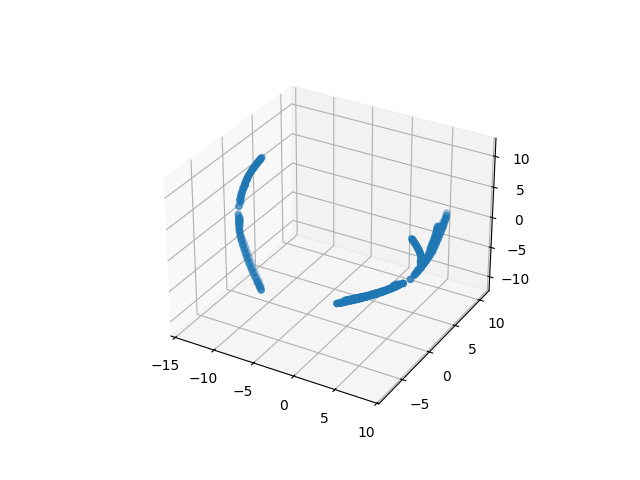

In [ ]:
#fig, ax = plt.subplots()
#ax.scatter(MDS[:, 0], MDS[:, 1],  MDS[:, 2])

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(*np.moveaxis(MDS, -1, 0))
#visualize_MDS_Graph(MDS, M)